import libraries


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk
import string
import seaborn as sns
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load Dataset

In [ ]:
fake = pd.read_csv('Fake.csv', engine='python', on_bad_lines='skip')
true = pd.read_csv('True.csv', engine='python', on_bad_lines='skip')

labels

In [ ]:
fake['label'] = 0
true['label'] = 1

Combine

In [ ]:
df = pd.concat([fake, true], ignore_index=True)

In [ ]:
df.head(10)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [ ]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
0,52.548902
1,47.451098


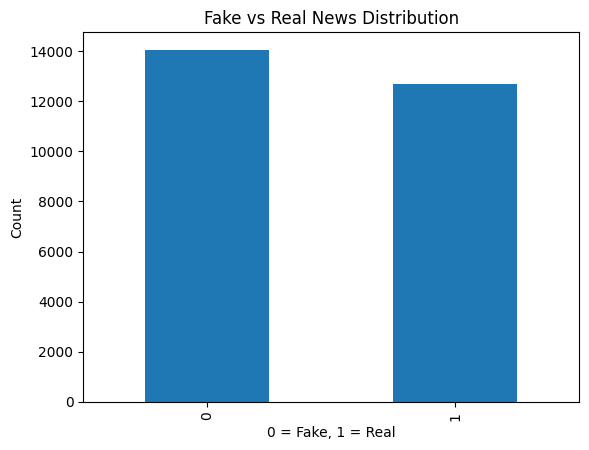

In [ ]:
df['label'].value_counts().plot(kind='bar')
plt.title("Fake vs Real News Distribution")
plt.xlabel("0 = Fake, 1 = Real")
plt.ylabel("Count")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26737 entries, 0 to 26736
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    26737 non-null  object
 1   text     26737 non-null  object
 2   subject  26737 non-null  object
 3   date     26737 non-null  object
 4   label    26737 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.0+ MB


In [ ]:
df.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


**conver date datatype from object to dateTime**

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   title    44898 non-null  object        
 1   text     44898 non-null  object        
 2   subject  44898 non-null  object        
 3   date     11868 non-null  datetime64[ns]
 4   label    44898 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 1.7+ MB


In [ ]:
df.isna().sum()

,0
title,0
text,0
subject,0
date,33030
label,0


In [ ]:
df.drop('date',axis=1,inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(168)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26569 entries, 0 to 26736
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    26569 non-null  object
 1   text     26569 non-null  object
 2   subject  26569 non-null  object
 3   label    26569 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.0+ MB


In [ ]:
df['subject'].unique()

array(['News', 'politics', 'politicsNews', 'worldnews'], dtype=object)

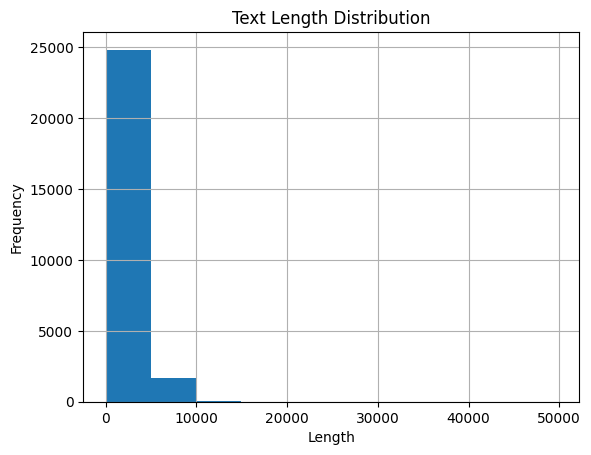

In [ ]:
df['text_length'] = df['text'].str.len()

df['text_length'].hist()
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df.shape

(26569, 5)

Clean

In [ ]:
df['final_text'] = df['text'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation)).lower()
)

*Tokenization*

In [ ]:
df['final_text'] = df['final_text'].apply(lambda x: word_tokenize(x))

### **Stop word removal**

In [ ]:
stop_words = set(stopwords.words('english'))

df['final_text'] = df['final_text'].apply( lambda x : [word for word in x if  word  not in stop_words ] )

### POS **Tagging**

In [ ]:
label = df['label']
df = df.drop(columns=['label'])

In [ ]:
df['final_text'] = df['final_text'].apply(lambda x: nltk.pos_tag(x))

### **Lemmatization**

In [ ]:
def lemmatize_word(my_tuple):
    tag_dic = {
        'N': wn.NOUN,
        'V': wn.VERB,
        'R': wn.ADV,
        'J': wn.ADJ
        }

    pos_tag = my_tuple[1][0].upper() if my_tuple[1] else 'N' # (V)V take first letter
    tag = tag_dic.get(pos_tag, wn.NOUN)

    word = my_tuple[0]

    lemmatizer = WordNetLemmatizer()

    return lemmatizer.lemmatize(word, tag)

In [ ]:
lemmatizer = WordNetLemmatizer()
df['final_text'] = df['final_text'].apply(lambda text : [lemmatize_word(my_tuple) for my_tuple in text])

In [ ]:
df.head()

,title,text,subject,text_length,final_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2893,"[donald, trump, wish, american, happy, new, ye..."
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,1898,"[house, intelligence, committee, chairman, dev..."
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,3597,"[friday, reveal, former, milwaukee, sheriff, d..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2774,"[christmas, day, donald, trump, announce, woul..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2346,"[pope, francis, use, annual, christmas, day, m..."


### **Feature Extraction**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# =========================
# Text + Labels
# =========================
X = df['final_text'].apply(lambda x: " ".join(x))
y = label

# =========================
# Train / Test Split FIRST
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Bag of Words
# =========================
bow_vectorizer = CountVectorizer(max_features=3000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# =========================
# TF-IDF
# =========================
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("BoW shape:", X_train_bow.shape, X_test_bow.shape)
print("TF-IDF shape:", X_train_tfidf.shape, X_test_tfidf.shape)

BoW shape: (21255, 3000) (5314, 3000)
TF-IDF shape: (21255, 3000) (5314, 3000)


# train model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n" + "="*50)
print("LOGISTIC REGRESSION (TF-IDF)")
print("="*50)

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


LOGISTIC REGRESSION (TF-IDF)
Accuracy: 0.9856981558148288

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2828
           1       0.99      0.98      0.98      2486

    accuracy                           0.99      5314
   macro avg       0.99      0.99      0.99      5314
weighted avg       0.99      0.99      0.99      5314


Confusion Matrix:
 [[2791   37]
 [  39 2447]]


In [ ]:
from sklearn.naive_bayes import MultinomialNB
print("\n" + "="*50)
print("NAIVE BAYES (TF-IDF)")
print("="*50)

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


NAIVE BAYES (TF-IDF)
Accuracy: 0.9273616861121565

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93      2828
           1       0.92      0.93      0.92      2486

    accuracy                           0.93      5314
   macro avg       0.93      0.93      0.93      5314
weighted avg       0.93      0.93      0.93      5314


Confusion Matrix:
 [[2624  204]
 [ 182 2304]]


In [ ]:
print("\n" + "="*50)
print("LOGISTIC REGRESSION (BoW)")
print("="*50)

log_reg_bow = LogisticRegression(max_iter=1000)

log_reg_bow.fit(X_train_bow, y_train)

y_pred_lr_bow = log_reg_bow.predict(X_test_bow)

print("Accuracy:", accuracy_score(y_test, y_pred_lr_bow))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_bow))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_bow))


LOGISTIC REGRESSION (BoW)
Accuracy: 0.9939781708694015

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2828
           1       0.99      0.99      0.99      2486

    accuracy                           0.99      5314
   macro avg       0.99      0.99      0.99      5314
weighted avg       0.99      0.99      0.99      5314


Confusion Matrix:
 [[2811   17]
 [  15 2471]]


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n" + "="*50)
print("NAIVE BAYES (BoW)")
print("="*50)

nb_bow = MultinomialNB()

nb_bow.fit(X_train_bow, y_train)

y_pred_nb_bow = nb_bow.predict(X_test_bow)

print("Accuracy:", accuracy_score(y_test, y_pred_nb_bow))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb_bow))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_bow))


NAIVE BAYES (BoW)
Accuracy: 0.9392171622130222

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      2828
           1       0.93      0.94      0.94      2486

    accuracy                           0.94      5314
   macro avg       0.94      0.94      0.94      5314
weighted avg       0.94      0.94      0.94      5314


Confusion Matrix:
 [[2642  186]
 [ 137 2349]]
